# Notebook 30 — Branch B: Pose Regression (Stage 3)

Train **Branch B** for full-pose regression from depth sequences using pseudo-labels generated from the custom dataset.

**Architecture:**
```
Pretrained Backbone (frozen):
  Input: (B, 1, 16, 64, 64)
  → 3D CNN + Transformer → (B, 128)

Branch B Head (trainable):
  (B, 128) → Linear(128→64) → ReLU → Linear(64→22*3) → (B, 22, 3)
```

**Training Strategy:**
- Freeze backbone + Branch A, train only Branch B head
- Use SmoothL1 loss for robust regression on pseudo-labeled data
- Track per-joint and overall L2 error in meters

## Table of Contents
1. [Environment & Imports](#1)
2. [Load Data](#2)
3. [Build Model with Branch B](#3)
4. [Training Loop](#4)
5. [Evaluation & Visualization](#5)
6. [Save Model](#6)


---
## 1. Environment & Imports <a id='1'></a>

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# Set paths
SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

from config import PROC_DIR

CUSTOM_PROC_DIR = PROC_DIR / 'custom'
MODELS_DIR = PROC_DIR.parent / 'models'
MODELS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# Random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Bone connections for visualization
BONES = [
    (0,1),(0,2),(2,3),(3,4),(4,5),
    (1,6),(6,7),(7,8),(8,9),
    (1,10),(10,11),(11,12),(12,13),
    (1,14),(14,15),(15,16),(16,17),
    (1,18),(18,19),(19,20),(20,21)
]
NUM_JOINTS = 22

Device: cuda
PyTorch: 2.11.0+cu130


---
## 2. Load Data <a id='2'></a>

In [2]:
class CustomDepthDataset(torch.utils.data.Dataset):
    """Load custom prepared depth dataset."""
    def __init__(self, npz_path):
        data = np.load(npz_path)
        self.X = torch.from_numpy(data['X']).unsqueeze(1)  # (M, 1, T, 64, 64)
        self.y = torch.from_numpy(data['y']).float()       # (M, 22, 3)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].float(), self.y[idx]

# Load datasets (Branch B uses pose labels)
print('Loading custom dataset for Branch B...')
train_ds = CustomDepthDataset(CUSTOM_PROC_DIR / 'branch_b_train.npz')
val_ds = CustomDepthDataset(CUSTOM_PROC_DIR / 'branch_b_val.npz')
test_ds = CustomDepthDataset(CUSTOM_PROC_DIR / 'branch_b_test.npz')

print(f'Train: {len(train_ds)} windows')
print(f'Val:   {len(val_ds)} windows')
print(f'Test:  {len(test_ds)} windows')

# Check sample
x_sample, y_sample = train_ds[0]
print(f'\nSample shapes:')
print(f'  X: {x_sample.shape}')
print(f'  y: {y_sample.shape} (22 joints × 3 coords)')

Loading custom dataset for Branch B...
Train: 172 windows
Val:   36 windows
Test:  52 windows

Sample shapes:
  X: torch.Size([1, 16, 64, 64])
  y: torch.Size([22, 3]) (22 joints × 3 coords)


---
## 3. Build Model with Branch B <a id='3'></a>

In [3]:
class DepthToSkeletonBackbone(nn.Module):
    """Backbone: CNN + Transformer."""
    def __init__(self, d_model=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3,5,5), padding=(1,2,2)),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),
            
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((1,2,2)),
            
            nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d((2,2,2)),
        )
        
        self.spatial_proj = nn.Linear(128, d_model)
        self.temporal_tokens = 8
        self.pos_enc = nn.Parameter(torch.randn(1, self.temporal_tokens, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=d_model*4,
            dropout=0.1, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
    
    def forward(self, depth):
        """(B, 1, T, 64, 64) → (B, 128)"""
        _, _, _, _, _ = depth.shape
        x = self.cnn(depth)
        B, C, T_new, _, _ = x.shape
        
        x = x.permute(0, 2, 1, 3, 4)
        x = x.reshape(B, T_new, C, -1).mean(dim=3)
        x = self.spatial_proj(x)
        x = x + self.pos_enc[:, :T_new, :]
        x = self.transformer(x)
        feat = x.mean(dim=1)
        
        return feat

class BranchBPoseModel(nn.Module):
    """Full model: frozen backbone + trainable Branch B head."""
    def __init__(self, num_joints=22, d_model=128):
        super().__init__()
        self.backbone = DepthToSkeletonBackbone(d_model=d_model)
        
        # Branch B: Pose regressor (128→64→22*3)
        self.branch_b = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_joints * 3),
        )
        self.num_joints = num_joints
    
    def forward(self, depth, return_features=False):
        """(B, 1, T, 64, 64) → (B, 22, 3)"""
        feat = self.backbone(depth)
        pose_flat = self.branch_b(feat)
        pose = pose_flat.view(-1, self.num_joints, 3)
        
        if return_features:
            return pose, feat
        return pose

# Initialize model
model = BranchBPoseModel(num_joints=NUM_JOINTS).to(device)
print('✓ Initialized Branch B model')

# Load backbone weights (from Stage 1)
backbone_path = PROC_DIR / 'stage1_best.pth'
if not backbone_path.exists():
    alt_paths = [
        PROC_DIR / 'pretrained_depth_backbone.pth',
        MODELS_DIR / 'stage1_pretrained_backbone.pth',
    ]
    for alt_path in alt_paths:
        if alt_path.exists():
            backbone_path = alt_path
            break

if backbone_path.exists():
    try:
        ckpt = torch.load(backbone_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(backbone_path, map_location=device)

    backbone_target = model.backbone.state_dict()
    if isinstance(ckpt, dict) and 'backbone' in ckpt:
        # Load from separated backbone dict
        backbone_state = ckpt['backbone']
        if isinstance(backbone_state, dict):
            if any(k.startswith('backbone.') for k in backbone_state.keys()):
                backbone_state = {
                    k.replace('backbone.', '', 1): v
                    for k, v in backbone_state.items()
                    if k.startswith('backbone.')
                }
            filtered = {k: v for k, v in backbone_state.items() if k in backbone_target}
            model.backbone.load_state_dict(filtered, strict=False)
        print('✓ Loaded backbone from Stage 1')
    elif isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        backbone_dict = {
            k.replace('backbone.', '', 1): v
            for k, v in ckpt['model_state_dict'].items()
            if k.startswith('backbone.')
        }
        filtered = {k: v for k, v in backbone_dict.items() if k in backbone_target}
        model.backbone.load_state_dict(filtered, strict=False)
        print('✓ Loaded backbone from full model')
    else:
        # Plain state dict fallback
        plain_dict = ckpt if isinstance(ckpt, dict) else {}
        if any(k.startswith('backbone.') for k in plain_dict.keys()):
            plain_dict = {
                k.replace('backbone.', '', 1): v
                for k, v in plain_dict.items()
                if k.startswith('backbone.')
            }
        filtered = {k: v for k, v in plain_dict.items() if k in backbone_target}
        if filtered:
            model.backbone.load_state_dict(filtered, strict=False)
            print('✓ Loaded backbone from checkpoint')
        else:
            print(f'⚠ No compatible backbone weights found in {backbone_path}')
else:
    print(f'⚠ Backbone checkpoint not found: {backbone_path}')

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False
print('✓ Frozen backbone')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters:')
print(f'  Total:     {total_params:,}')
print(f'  Trainable: {trainable_params:,} (Branch B head only)')

✓ Initialized Branch B model
✓ Loaded backbone from full model
✓ Frozen backbone

Model parameters:
  Total:     904,450
  Trainable: 12,546 (Branch B head only)


---
## 4. Training Loop <a id='4'></a>

In [4]:
# Hyperparameters
BATCH_SIZE = 8
NUM_EPOCHS = 80
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True if device.type == 'cuda' else False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True if device.type == 'cuda' else False)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Loss function: SmoothL1 is robust to pseudo-label noise
criterion = nn.SmoothL1Loss(beta=0.1, reduction='mean')

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],     # Mean Absolute Error in original units
    'val_rmse': [],    # Root Mean Squared Error
}

best_val_mae = float('inf')
patience_counter = 0
MAX_PATIENCE = 20

print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {NUM_EPOCHS}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Loss: SmoothL1 (beta=0.1)')
print(f'Early stopping patience: {MAX_PATIENCE}\n')

Batch size: 8
Epochs: 80
Learning rate: 0.001
Loss: SmoothL1 (beta=0.1)
Early stopping patience: 20



In [5]:
# Training loop
for epoch in range(NUM_EPOCHS):
    # ─── TRAIN ───
    model.train()
    train_loss_accum = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', dynamic_ncols=True)
    for batch_idx, (depth, pose_target) in enumerate(pbar):
        depth = depth.to(device, non_blocking=True)
        pose_target = pose_target.to(device, non_blocking=True)
        
        pose_pred = model(depth)  # (B, 22, 3)
        loss = criterion(pose_pred, pose_target)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss_accum += loss.item()
        
        if batch_idx % 5 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss = train_loss_accum / len(train_loader)
    history['train_loss'].append(train_loss)
    
    # ─── VALIDATION ───
    model.eval()
    val_loss_accum = 0.0
    val_errors = []  # Per-joint L2 distances
    
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]', dynamic_ncols=True)
        for depth, pose_target in pbar_val:
            depth = depth.to(device, non_blocking=True)
            pose_target = pose_target.to(device, non_blocking=True)
            
            pose_pred = model(depth)
            loss = criterion(pose_pred, pose_target)
            val_loss_accum += loss.item()
            
            # Compute per-joint L2 error (in pseudo-label units)
            diff = pose_pred - pose_target  # (B, 22, 3)
            joint_errors = torch.norm(diff, dim=2)  # (B, 22) — L2 per joint
            val_errors.append(joint_errors.cpu().numpy())
    
    val_loss = val_loss_accum / len(val_loader)
    val_errors = np.concatenate(val_errors, axis=0)  # (N_windows, 22)
    
    val_mae = val_errors.mean()
    val_rmse = np.sqrt((val_errors ** 2).mean())
    
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}:')
    print(f'  Train loss: {train_loss:.4f}')
    print(f'  Val loss:   {val_loss:.4f}')
    print(f'  Val MAE:    {val_mae:.4f}  Val RMSE: {val_rmse:.4f}')
    print(f'  LR:         {optimizer.param_groups[0]["lr"]:.2e}')
    
    # Early stopping based on MAE
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_mae': val_mae,
            'val_rmse': val_rmse,
        }, MODELS_DIR / 'branch_b_best.pth')
        print(f'  ✓ Best model saved (MAE={val_mae:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{MAX_PATIENCE})')
        
        if patience_counter >= MAX_PATIENCE:
            print(f'  → Early stopping at epoch {epoch+1}')
            break
    
    scheduler.step()

print('\n' + '='*60)
print('Training complete!')
print('='*60)

Epoch 1/80 [Train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1/80 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1/80:
  Train loss: 0.0554
  Val loss:   0.0608
  Val MAE:    0.1943  Val RMSE: 0.2146
  LR:         1.00e-03
  ✓ Best model saved (MAE=0.1943)


Epoch 2/80 [Train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2/80 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 24/80 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 24/80:
  Train loss: 0.0008
  Val loss:   0.0247
  Val MAE:    0.0954  Val RMSE: 0.1274
  LR:         5.00e-04
  No improvement (19/20)


Epoch 25/80 [Train]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 25/80 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 25/80:
  Train loss: 0.0008
  Val loss:   0.0255
  Val MAE:    0.0963  Val RMSE: 0.1300
  LR:         5.00e-04
  No improvement (20/20)
  → Early stopping at epoch 25

Training complete!


---
## 5. Evaluation & Visualization <a id='5'></a>

Loaded best model from epoch 4
  Val MAE: 0.0888  Val RMSE: 0.1154


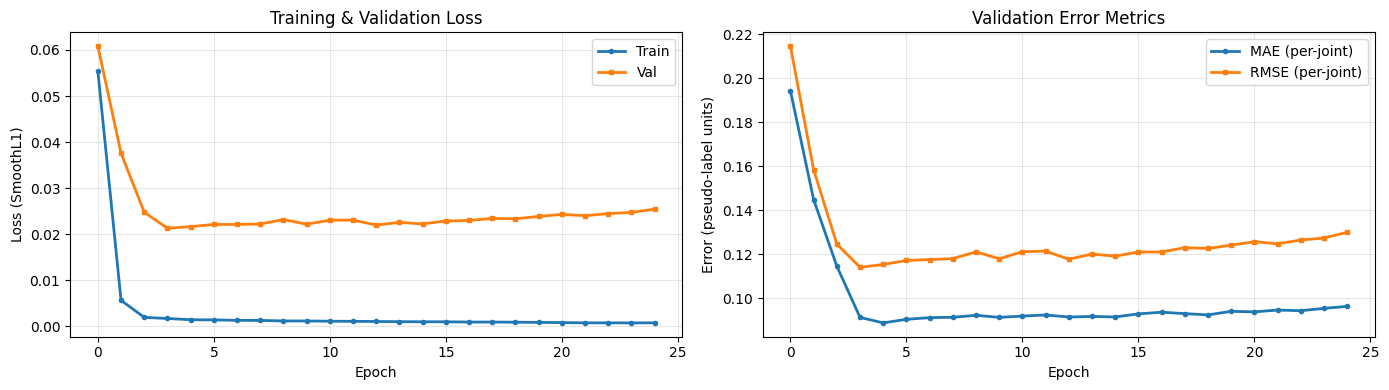

✓ Saved training curves


In [6]:
# Load best model
best_path = MODELS_DIR / 'branch_b_best.pth'
if not best_path.exists():
    raise FileNotFoundError(f'Best checkpoint not found: {best_path}')

try:
    best_ckpt = torch.load(best_path, map_location=device, weights_only=False)
except TypeError:
    # Older PyTorch versions do not accept weights_only
    best_ckpt = torch.load(best_path, map_location=device)

model.load_state_dict(best_ckpt['model_state_dict'])
print(f'Loaded best model from epoch {best_ckpt["epoch"]}')
print(f'  Val MAE: {best_ckpt["val_mae"]:.4f}  Val RMSE: {best_ckpt["val_rmse"]:.4f}')

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
axes[0].plot(history['val_loss'], label='Val', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (SmoothL1)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error curves
axes[1].plot(history['val_mae'], label='MAE (per-joint)', linewidth=2, marker='o', markersize=3)
axes[1].plot(history['val_rmse'], label='RMSE (per-joint)', linewidth=2, marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error (pseudo-label units)')
axes[1].set_title('Validation Error Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'branch_b_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved training curves')

In [7]:
# Evaluate on test set
model.eval()
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_errors = []
all_preds = []
all_targets = []

with torch.no_grad():
    for depth, pose_target in tqdm(test_loader, desc='Testing'):
        depth = depth.to(device)
        pose_target = pose_target.to(device)
        
        pose_pred = model(depth)
        
        diff = pose_pred - pose_target
        joint_errors = torch.norm(diff, dim=2)  # (B, 22)
        all_errors.append(joint_errors.cpu().numpy())
        all_preds.append(pose_pred.cpu().numpy())
        all_targets.append(pose_target.cpu().numpy())

all_errors = np.concatenate(all_errors, axis=0)    # (N, 22)
all_preds = np.concatenate(all_preds, axis=0)      # (N, 22, 3)
all_targets = np.concatenate(all_targets, axis=0)  # (N, 22, 3)

test_mae = all_errors.mean()
test_rmse = np.sqrt((all_errors ** 2).mean())
per_joint_mae = all_errors.mean(axis=0)

print('\nTest Set Results:')
print(f'  Overall MAE:  {test_mae:.4f}')
print(f'  Overall RMSE: {test_rmse:.4f}')
print(f'\nPer-joint MAE (first 10 joints):')
for j in range(min(10, NUM_JOINTS)):
    print(f'    Joint {j:2d}: {per_joint_mae[j]:.4f}')

Testing:   0%|          | 0/7 [00:00<?, ?it/s]


Test Set Results:
  Overall MAE:  0.0181
  Overall RMSE: 0.0201

Per-joint MAE (first 10 joints):
    Joint  0: 0.0215
    Joint  1: 0.0122
    Joint  2: 0.0156
    Joint  3: 0.0175
    Joint  4: 0.0130
    Joint  5: 0.0220
    Joint  6: 0.0180
    Joint  7: 0.0151
    Joint  8: 0.0152
    Joint  9: 0.0120


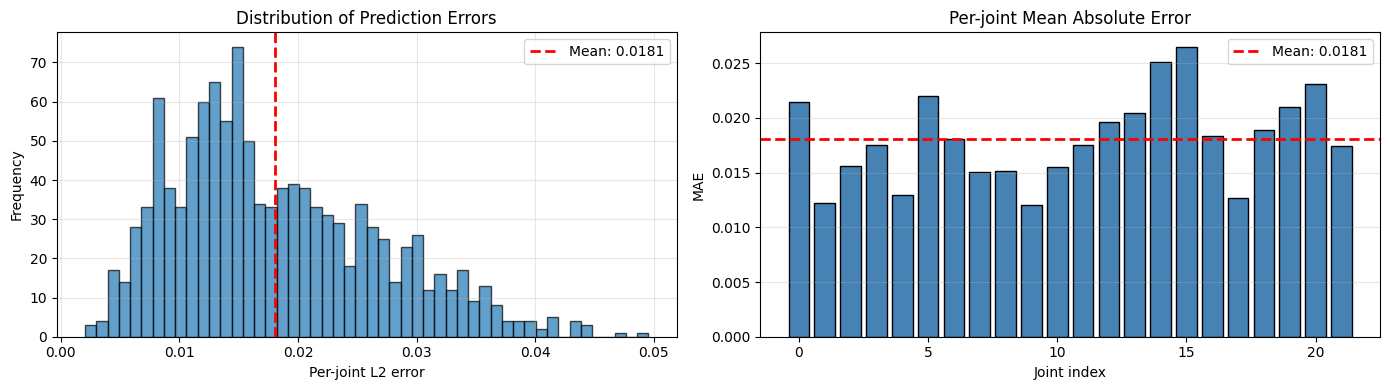

✓ Saved error analysis


In [8]:
# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of per-joint errors
axes[0].hist(all_errors.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(test_mae, color='red', linestyle='--', linewidth=2, label=f'Mean: {test_mae:.4f}')
axes[0].set_xlabel('Per-joint L2 error')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-joint error bar chart
axes[1].bar(range(NUM_JOINTS), per_joint_mae, color='steelblue', edgecolor='black')
axes[1].axhline(test_mae, color='red', linestyle='--', linewidth=2, label=f'Mean: {test_mae:.4f}')
axes[1].set_xlabel('Joint index')
axes[1].set_ylabel('MAE')
axes[1].set_title('Per-joint Mean Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'branch_b_error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved error analysis')

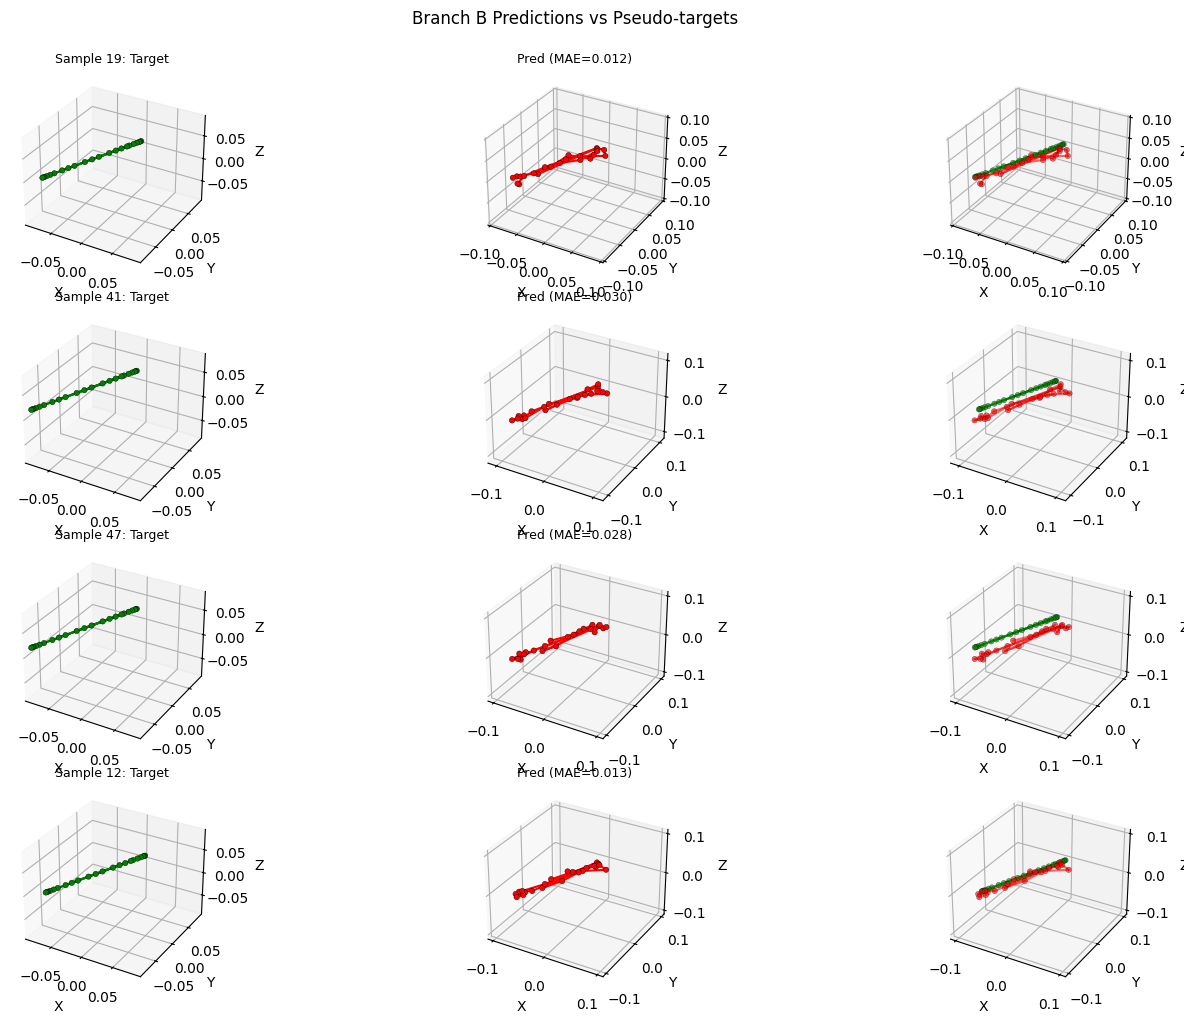

✓ Saved prediction visualizations


In [9]:
# Visualize predictions vs targets for random test samples
def plot_skeleton_3d(ax, skeleton, title='', color='blue', alpha=1.0):
    """Plot 3D skeleton."""
    for i, j in BONES:
        ax.plot([skeleton[i,0], skeleton[j,0]],
                [skeleton[i,1], skeleton[j,1]],
                [skeleton[i,2], skeleton[j,2]],
                c=color, lw=1.5, alpha=alpha)
    
    ax.scatter(skeleton[:,0], skeleton[:,1], skeleton[:,2],
               c=color, s=15, alpha=alpha, edgecolors='k', linewidths=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title, fontsize=9)
    
    max_range = np.abs(skeleton).max()
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])

# Select 4 random samples
sample_indices = np.random.choice(len(all_preds), 4, replace=False)

fig = plt.figure(figsize=(16, 10))
for plot_idx, sample_idx in enumerate(sample_indices):
    pred = all_preds[sample_idx]   # (22, 3)
    target = all_targets[sample_idx]  # (22, 3)
    error = all_errors[sample_idx]    # (22,)
    
    # Plot target
    ax1 = fig.add_subplot(4, 3, plot_idx*3 + 1, projection='3d')
    plot_skeleton_3d(ax1, target, title=f'Sample {sample_idx}: Target', color='green')
    
    # Plot prediction
    ax2 = fig.add_subplot(4, 3, plot_idx*3 + 2, projection='3d')
    plot_skeleton_3d(ax2, pred, title=f'Pred (MAE={error.mean():.3f})', color='red')
    
    # Overlay
    ax3 = fig.add_subplot(4, 3, plot_idx*3 + 3, projection='3d')
    plot_skeleton_3d(ax3, target, title='Overlay', color='green', alpha=0.6)
    plot_skeleton_3d(ax3, pred, title='', color='red', alpha=0.6)

fig.suptitle('Branch B Predictions vs Pseudo-targets', fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'branch_b_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved prediction visualizations')

---
## 6. Save Model <a id='6'></a>

In [10]:
# Save final model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'training_info': {
        'stage': 3,
        'task': 'pose_regression',
        'num_joints': NUM_JOINTS,
        'best_epoch': best_ckpt['epoch'],
        'val_mae': float(best_ckpt['val_mae']),
        'val_rmse': float(best_ckpt['val_rmse']),
        'test_mae': float(test_mae),
        'test_rmse': float(test_rmse),
    }
}, MODELS_DIR / 'branch_b_final.pth')

print('✓ Saved final model')
print(f'  Path: {MODELS_DIR / "branch_b_final.pth"}')
print(f'\nBranch B (Pose Regressor)')
print(f'  Input:  (B, 1, 16, 64, 64) depth sequences')
print(f'  Output: (B, 22, 3) joint coordinates')
print(f'  Best validation MAE: {float(best_ckpt["val_mae"]):.4f}')
print(f'  Test MAE: {test_mae:.4f}')
print(f'  Test RMSE: {test_rmse:.4f}')

✓ Saved final model
  Path: D:\course\comp4471\comp4471-project\dataset\models\branch_b_final.pth

Branch B (Pose Regressor)
  Input:  (B, 1, 16, 64, 64) depth sequences
  Output: (B, 22, 3) joint coordinates
  Best validation MAE: 0.0888
  Test MAE: 0.0181
  Test RMSE: 0.0201


In [11]:
# Summary
print('\n' + '='*70)
print('CUSTOM DATA TRAINING COMPLETE')
print('='*70)
print(f'\nSaved artifacts in: {MODELS_DIR}')
print(f'\nBranch A (Intention Classification):')
print(f'  ✓ branch_a_best.pth (checkpoint)')
print(f'  ✓ branch_a_final.pth (final model)')
print(f'  ✓ branch_a_training_curves.png')
print(f'  ✓ branch_a_confusion_matrix.png')
print(f'\nBranch B (Pose Regression):')
print(f'  ✓ branch_b_best.pth (checkpoint)')
print(f'  ✓ branch_b_final.pth (final model)')
print(f'  ✓ branch_b_training_curves.png')
print(f'  ✓ branch_b_error_analysis.png')
print(f'  ✓ branch_b_predictions.png')
print(f'\nNext step: Combine both branches for inference')
print('='*70)


CUSTOM DATA TRAINING COMPLETE

Saved artifacts in: D:\course\comp4471\comp4471-project\dataset\models

Branch A (Intention Classification):
  ✓ branch_a_best.pth (checkpoint)
  ✓ branch_a_final.pth (final model)
  ✓ branch_a_training_curves.png
  ✓ branch_a_confusion_matrix.png

Branch B (Pose Regression):
  ✓ branch_b_best.pth (checkpoint)
  ✓ branch_b_final.pth (final model)
  ✓ branch_b_training_curves.png
  ✓ branch_b_error_analysis.png
  ✓ branch_b_predictions.png

Next step: Combine both branches for inference
